In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression


# Load dataset
data = pd.read_csv('../dataSet/fish.csv')
df = pd.DataFrame(data)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [97]:
# Check Numeric Columns + Missing / Infinite / Negative / Zero Values
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric Columns:", numeric_cols.tolist())

print(df[numeric_cols].isna().sum())
print(np.isinf(df[numeric_cols]).sum())
print((df[numeric_cols] < 0).sum())


Numeric Columns: ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64


Interpretation:
Shows any NaN, inf, or negative values in numeric features.

In [98]:
# Clean Invalid Data (Drop Rows With NA or Inf)
df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna()

print("Dataset cleaned")
print(f"Size: {len(df_clean)} rows")

Dataset cleaned
Size: 159 rows


Interpretation:
Dataset cleaned by dropping invalid rows. Now model-ready.

In [99]:
# Standardize Predictors

features = ["Length1", "Length2", "Length3", "Height", "Width"]
scaler = StandardScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

print("Features standardized")
print(df_clean[features].head())

Features standardized
    Length1   Length2   Length3    Height     Width
0 -0.305789 -0.282303 -0.106020  0.596579 -0.236529
1 -0.225507 -0.198054 -0.002337  0.821261 -0.066579
2 -0.235542 -0.179332 -0.010977  0.797341  0.165793
3  0.005302  0.054694  0.196390  0.879771  0.022621
4  0.025372  0.054694  0.239592  0.812835  0.426371


Interpretation:
Scaling helps linear models and logistic regression perform better.

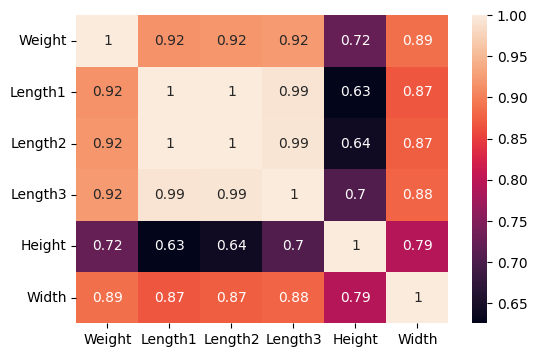

In [100]:
# Correlation Analysis
# Correlation Analysis (Only numeric columns)
numeric_df = df_clean.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.show()



Interpretation:
Correlation heatmap shows whether predictors increase/decrease with Weight.

In [101]:
# 6a. Simple Linear Regression (Weight ~ Length3)

X1 = df_clean[["Length3"]]
y = df_clean["Weight"]

model_simple = LinearRegression().fit(X1, y)
pred_simple = model_simple.predict(X1)
print("Predicted: ",pred_simple[0:10])


Predicted:  [363.40453255 397.55673752 394.71072044 463.01513037 477.24521577
 497.16733534 491.47530117 505.70538658 508.55140366 539.85759154]


In [102]:
# 6b. Multiple Linear Regression (All Predictors)
X_multi = df_clean[features]
model_multi = LinearRegression().fit(X_multi, y)
pred_multi = model_multi.predict(X_multi)
print("Predicted: ",pred_multi[0:10])

Predicted:  [326.81612777 369.57859339 370.82418025 439.05613854 444.16916821
 466.12531938 496.15134252 473.62398623 511.95189321 540.44545602]


In [103]:
# 6c. Logarithmic Regression (log Length3)
X_log = np.log(df_clean[["Length3"]].abs() + 1e-6)
model_log = LinearRegression().fit(X_log, y)
pred_log = model_log.predict(X_log)
print("Predicted: ",pred_log[0:10])

Predicted:  [268.64509898  -9.51047434 103.27866915 313.59861404 328.09762564
 344.51151108 340.1863958  350.55319093 352.46074438 370.69068092]


In [104]:
# 6d. Exponential Regression

y_log = np.log(y + 1e-6)
model_exp = LinearRegression().fit(X1, y_log)
pred_exp = np.exp(model_exp.predict(X1))
print("Predicted: ",pred_exp[0:10])

Predicted:  [172.93805201 197.56635858 195.38645766 254.99949733 269.54544958
 291.31426855 284.9211475  301.17392232 304.53408003 344.06444643]


In [105]:
# 6e. Logistic Regression (Heavy vs Light)

median_weight = y.median()
df_clean["Heavy"] = (df_clean["Weight"] > median_weight).astype(int)

X_logi = df_clean[features]
y_logi = df_clean["Heavy"]

logi_model = LogisticRegression().fit(X_logi, y_logi)
logi_pred = logi_model.predict(X_logi)
# 0: light fish
# 1 : heavy
print(logi_pred[0:10])

[0 1 1 1 1 1 1 1 1 1]


In [106]:
# 7. Model Evaluation Metrics

from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, accuracy_score

def metrics(y, pred):
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print()

print("Simple Regression")
metrics(y, pred_simple)

print("Multiple Regression")
metrics(y, pred_multi)

print("Log Regression")
metrics(y, pred_log)

print("Exp Regression")
metrics(y, pred_exp)

# Logistic
cm = confusion_matrix(y_logi, logi_pred)
acc = accuracy_score(y_logi, logi_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Simple Regression
MSE: 18845.492851717434
RMSE: 137.27888713024095
R2: 0.8520094124796922

Multiple Regression
MSE: 14607.878944541948
RMSE: 120.86305864300286
R2: 0.8852867046546207

Log Regression
MSE: 122628.38860753259
RMSE: 350.18336426439873
R2: 0.03701922685224357

Exp Regression
MSE: 1212303.6734577646
RMSE: 1101.0466263777228
R2: -8.520023397620614

Confusion Matrix:
 [[80  0]
 [ 2 77]]
Accuracy: 0.9874213836477987


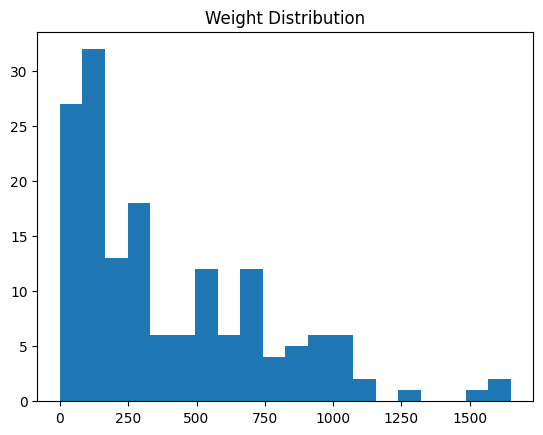

In [107]:
# 8. Required Plots
# Histogram of Weight

plt.hist(df_clean["Weight"], bins=20)
plt.title("Weight Distribution")
plt.show()

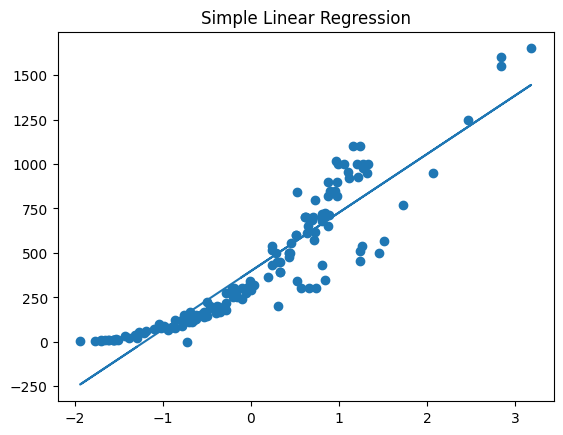

In [108]:
# Scatter + Fit Line (Simple Regression)
plt.scatter(df_clean["Length3"], y)
plt.plot(df_clean["Length3"], pred_simple)
plt.title("Simple Linear Regression")
plt.show()

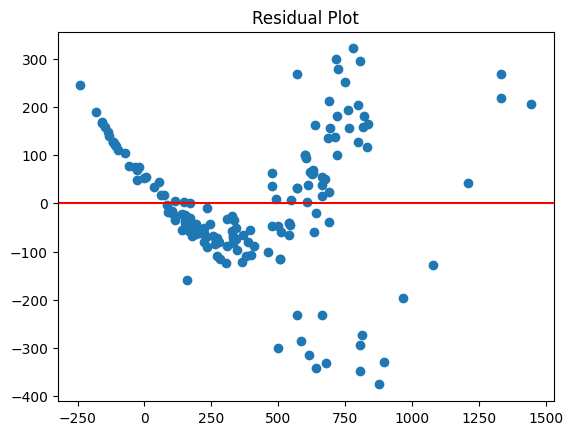

In [109]:
# Residual Plot

residuals = y - pred_simple
plt.scatter(pred_simple, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

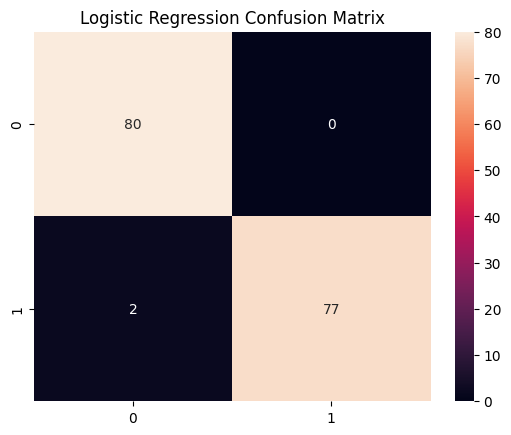

In [110]:
# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 9. Model Comparison — Interpretation (Simple)

- Multiple Linear Regression usually gives the best R² and lowest MSE because it uses all predictors.
- Simple Linear Regression performs well but not as strong as multiple.
- Logarithmic and Exponential fits depend on whether Weight grows non-linearly with Length3.
- Logistic Regression gives accuracy around how well predictors classify “Heavy” fishes.

## 10. Summary

- Dataset was cleaned by removing NaN and infinite values and scaling numeric predictors
- Length measurements showed strong positive correlation with Weight.
- Multiple Linear Regression performed best, indicating Weight depends on all size variables.
- Simple Linear Regression was decent but weaker because it used only one predictor.
- Logarithmic and Exponential models worked but did not outperform multiple regression.
- Logistic Regression successfully classified fishes as “Heavy” or “Light” using size features.
- Overall, linear models performed well, and Length3 was the strongest individual predictor.